In [11]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import ast, os
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [ ]:
DATA_PATH = "/kaggle/input/competitions/quickdraw-doodle-recognition/train_simplified"

NUM_CLASSES = 100
SAMPLES_PER_CLASS = 20000

MAX_SEQ_LEN = 200
BATCH_SIZE = 128
HIDDEN_SIZE = 256
EPOCHS = 5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [84]:
all_files = sorted(os.listdir(DATA_PATH))

class_names = [f.replace(".csv", "") for f in all_files[:NUM_CLASSES]]

class_to_idx = {cls: i for i, cls in enumerate(class_names)}

In [15]:
def strokes_to_5d(strokes):
    seq = []
    
    for stroke in strokes:
        x, y = stroke
        
        for i in range(len(x)):
            if i == 0:
                dx, dy = 0, 0
            else:
                dx = (x[i] - x[i-1]) / 255.0
                dy = (y[i] - y[i-1]) / 255.0
            
            seq.append([dx, dy, 1, 0, 0])
        
        seq[-1][2] = 0
        seq[-1][3] = 1
    
    seq.append([0, 0, 0, 0, 1])
    return seq

In [16]:
def pad_sequence(seq, max_len=200):
    if len(seq) > max_len:
        return seq[:max_len]
    return seq + [[0,0,0,0,0]] * (max_len - len(seq))

In [17]:
class QuickDrawDataset(Dataset):
    def __init__(self, data_path, class_names):
        self.samples = []
        
        for cls in class_names:
            df = pd.read_csv(os.path.join(data_path, cls + ".csv"))
            
            for i in range(min(SAMPLES_PER_CLASS, len(df))):
                drawing = ast.literal_eval(df.iloc[i]["drawing"])
                self.samples.append((drawing, class_to_idx[cls]))
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        drawing, label = self.samples[idx]
        
        seq = strokes_to_5d(drawing)
        length = min(len(seq), MAX_SEQ_LEN)
        
        seq = pad_sequence(seq, MAX_SEQ_LEN)
        
        return (
            torch.tensor(seq, dtype=torch.float32),
            torch.tensor(label),
            length
        )

In [18]:
def collate_fn(batch):
    sequences, labels, lengths = zip(*batch)
    
    sequences = torch.stack(sequences)
    labels = torch.tensor(labels)
    lengths = torch.tensor(lengths, dtype=torch.long)
    
    return sequences, labels, lengths

In [65]:
dataset = QuickDrawDataset(DATA_PATH, class_names)

from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, collate_fn=collate_fn)

In [60]:
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size, hidden_size)
        self.context = nn.Linear(hidden_size, 1, bias=False)
    
    def forward(self, lstm_out, lengths):
        
        B, T, _ = lstm_out.size()
        
        scores = torch.tanh(self.attn(lstm_out))
        scores = self.context(scores).squeeze(-1)  # (B, T)
        
        
        device = lengths.device
        mask = torch.arange(T, device=device).expand(B, T) < lengths.unsqueeze(1)
        
        
        scores = scores.masked_fill(~mask, -1e4)
        
        weights = torch.softmax(scores, dim=1)
        
        context = torch.sum(lstm_out * weights.unsqueeze(-1), dim=1)
        
        return context, weights

In [43]:
class DoodleModel(nn.Module):
    def __init__(self, input_size=5, hidden_size=256, num_classes=20):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers=2,
            batch_first=True
        )
        
        self.attn = Attention(hidden_size)
        
        self.fc = nn.Sequential(
        nn.Linear(hidden_size, 128),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(128, num_classes)
    )
            
    def forward(self, x, lengths, hidden=None):
        lstm_out, hidden = self.lstm(x, hidden)   # (B, T, H)
        
        
        idx = (lengths - 1).unsqueeze(1).unsqueeze(2).expand(-1, 1, lstm_out.size(2))
        last_hidden = lstm_out.gather(1, idx).squeeze(1)   # (B, H)
        
        
        context, weights = self.attn(lstm_out, lengths)
        
        
        combined = context + last_hidden
        
        out = self.fc(combined)
        
        return out, weights

In [66]:
model = DoodleModel(num_classes=NUM_CLASSES).to(DEVICE)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

In [23]:
import os

CHECKPOINT_PATH = "checkpoint.pth"
BEST_MODEL_PATH = "best_model.pth"

start_epoch = 0
best_val_acc = 0.0

In [ ]:
import os

print(os.listdir("/kaggle/working"))
print(os.listdir("/kaggle/input/datasets/aghavvaishnavi/check1"))

In [67]:
CHECKPOINT_PATH = "checkpoint.pth"
if os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    start_epoch = checkpoint['epoch'] + 1
    best_val_acc = checkpoint.get('best_val_acc', 0.0)
    
    print(f" Resuming from epoch {start_epoch}")
else:
    print("Starting fresh training")

 Resuming from epoch 20


In [68]:
CHECKPOINT_PATH = "checkpoint.pth"

def evaluate(loader):
    model.eval()
    correct, total = 0, 0
    
    with torch.no_grad():
        for x, y, lengths in loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            lengths = lengths.to(DEVICE)   
            
            preds, _ = model(x, lengths)
            pred = torch.argmax(preds, dim=1)
            
            correct += (pred == y).sum().item()
            total += y.size(0)
    
    return (correct / total) * 100




for epoch in range(start_epoch, 50):
    model.train()
    
    total_loss = 0
    correct = 0
    total = 0
    
    for x, y, lengths in tqdm(train_loader):
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        lengths = lengths.to(DEVICE)   
        
        preds, _ = model(x, lengths)   
        
        loss = criterion(preds, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        predicted = torch.argmax(preds, dim=1)
        correct += (predicted == y).sum().item()
        total += y.size(0)
    
    train_acc = correct / total*100
    val_acc = evaluate(val_loader)
    
    print(f"Epoch {epoch+1}/{start_epoch+EPOCHS} Loss={total_loss/len(train_loader):.4f}, Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")
    
    
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print("Best model saved!")
    
    
    
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_val_acc': best_val_acc
    }, CHECKPOINT_PATH)

100%|██████████| 2500/2500 [02:48<00:00, 14.84it/s]


Epoch 21/25 Loss=1.2997, Train Acc=86.9788, Val Acc=87.9200
Best model saved!


100%|██████████| 2500/2500 [02:56<00:00, 14.17it/s]


Epoch 22/25 Loss=1.2468, Train Acc=88.5078, Val Acc=89.1950
Best model saved!


100%|██████████| 2500/2500 [02:55<00:00, 14.24it/s]


...

Epoch 48/25 Loss=0.9532, Train Acc=97.1275, Val Acc=91.4225


100%|██████████| 2500/2500 [02:55<00:00, 14.27it/s]


Epoch 49/25 Loss=0.9488, Train Acc=97.2506, Val Acc=91.4763


100%|██████████| 2500/2500 [02:55<00:00, 14.28it/s]


Epoch 50/25 Loss=0.9448, Train Acc=97.3719, Val Acc=91.5212


In [69]:
def streaming_predict(sample):
    model.eval()
    
    x, y, length = sample   
    seq = x.numpy()
    
    history = []
    
    for i in range(5, length+1, 5):
        chunk = seq[:i]
        
        chunk = pad_sequence(chunk.tolist(), MAX_SEQ_LEN)
        
        inp = torch.tensor(chunk, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        lengths = torch.tensor([i]).to(DEVICE)   # 🔥 FIX
        
        with torch.no_grad():
            out, _ = model(inp, lengths)
            probs = torch.softmax(out, dim=1)
        
        history.append(probs.cpu().numpy())
    
    return history

In [70]:
def plot_prediction(history):
    history = np.array(history).squeeze()
    
    avg_probs = history[-1]
    top_indices = np.argsort(avg_probs)[-5:][::-1]
    
    plt.figure(figsize=(10,5))
    
    for i in top_indices:
        plt.plot(history[:, i], label=class_names[i])
    
    plt.legend()
    plt.title("Prediction Over Time")
    plt.xlabel("Time Step")
    plt.ylabel("Probability")
    plt.show()

In [71]:
def prediction_over_time(sample):
    model.eval()
    
    x, y, length = sample  
    
    seq = x.numpy()
    
    for i in range(5, length, 5):
        partial = seq[:i]
        
        partial = pad_sequence(partial.tolist(), MAX_SEQ_LEN)
        
        inp = torch.tensor(partial, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        lengths = torch.tensor([i]).to(DEVICE)   # 🔥 FIX
        
        with torch.no_grad():
            out, _ = model(inp, lengths)
            pred = torch.argmax(out, dim=1).item()
        
        print(f"Step {i}: {class_names[pred]}")

In [72]:
def predict_topk(strokes):
    model.eval()
    
    seq = strokes_to_5d(strokes)
    seq = pad_sequence(seq, MAX_SEQ_LEN)
    
    seq = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        out, _, _ = model(seq)
        probs = torch.softmax(out, dim=1)
        topk = torch.topk(probs, 3)
    
    return [(class_names[i], float(p)) for i, p in zip(topk.indices[0], topk.values[0])]

In [73]:
def evaluate_early(dataset):
    model.eval()
    
    checkpoints = [0.5, 1.0]
    results = {c: [] for c in checkpoints}
    
    for x, y, length in dataset:   
        
        seq = x.numpy()
        
        for c in checkpoints:
            l = int(length * c)
            l = max(1, l)   # avoid zero
            
            partial = seq[:l]
            partial = pad_sequence(partial.tolist(), MAX_SEQ_LEN)
            
            inp = torch.tensor(partial, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            lengths = torch.tensor([l]).to(DEVICE)   
            
            with torch.no_grad():
                out, _ = model(inp, lengths)
                pred = torch.argmax(out, dim=1).item()
            
            results[c].append(pred == y.item())
    
    for c in checkpoints:
        print(f"{int(c*100)}% Accuracy:", np.mean(results[c]))

In [74]:
def evaluate_confusion(loader):
    model.eval()
    
    y_true, y_pred = [], []
    
    with torch.no_grad():
        for x, y, lengths in loader:   
            x = x.to(DEVICE)
            lengths = lengths.to(DEVICE)   
            
            preds, _ = model(x, lengths)
            pred = torch.argmax(preds, dim=1)
            
            y_true.extend(y.numpy())
            y_pred.extend(pred.cpu().numpy())
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()

In [75]:
test_acc = evaluate(val_loader)
print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 91.52%


In [76]:
x, y, length = dataset[0]

inp = x.unsqueeze(0).to(DEVICE)
lengths = torch.tensor([length]).to(DEVICE)   

with torch.no_grad():
    out, _ = model(inp, lengths)
    pred = torch.argmax(out, dim=1).item()

print("Actual:", class_names[y])
print("Predicted:", class_names[pred])

Actual: The Eiffel Tower
Predicted: The Eiffel Tower


In [77]:
def test_topk(sample_idx=0):
    x, y, length = dataset[sample_idx]
    
    inp = x.unsqueeze(0).to(DEVICE)
    lengths = torch.tensor([length]).to(DEVICE)
    
    with torch.no_grad():
        out, _ = model(inp, lengths)
        probs = torch.softmax(out, dim=1)
        topk = torch.topk(probs, 3)
    
    print("Actual:", class_names[y])
    
    for i, p in zip(topk.indices[0], topk.values[0]):
        print(class_names[i], float(p))

In [79]:
test_topk(2)

Actual: The Eiffel Tower
The Eiffel Tower 0.9249473214149475
The Great Wall of China 0.003548829350620508
The Mona Lisa 0.0009603305952623487


In [80]:
sample, y, _ = dataset[0]
drawing = sample.numpy().tolist()

prediction_over_time(dataset[0])

Step 5: animal migration
Step 10: The Great Wall of China
Step 15: arm
Step 20: The Eiffel Tower
Step 25: The Eiffel Tower
Step 30: The Eiffel Tower
Step 35: The Eiffel Tower


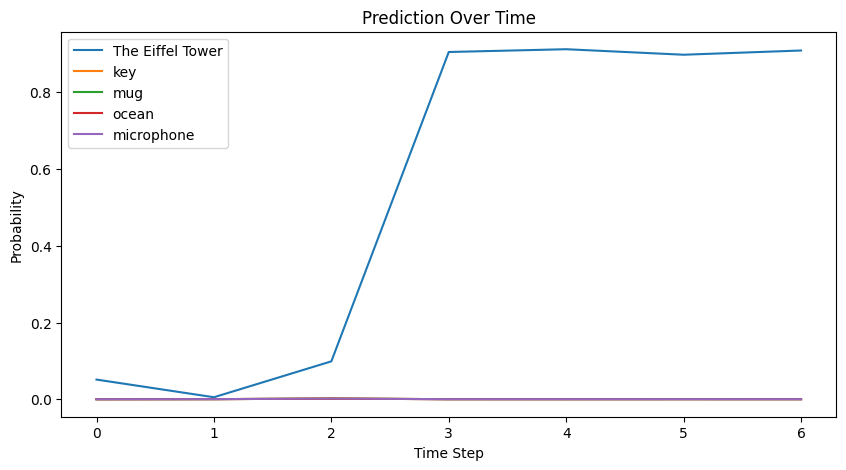

In [85]:
history = streaming_predict(dataset[0])
plot_prediction(history)

In [82]:
subset = torch.utils.data.Subset(dataset, range(1000))
evaluate_early(subset)

50% Accuracy: 0.644
100% Accuracy: 0.986


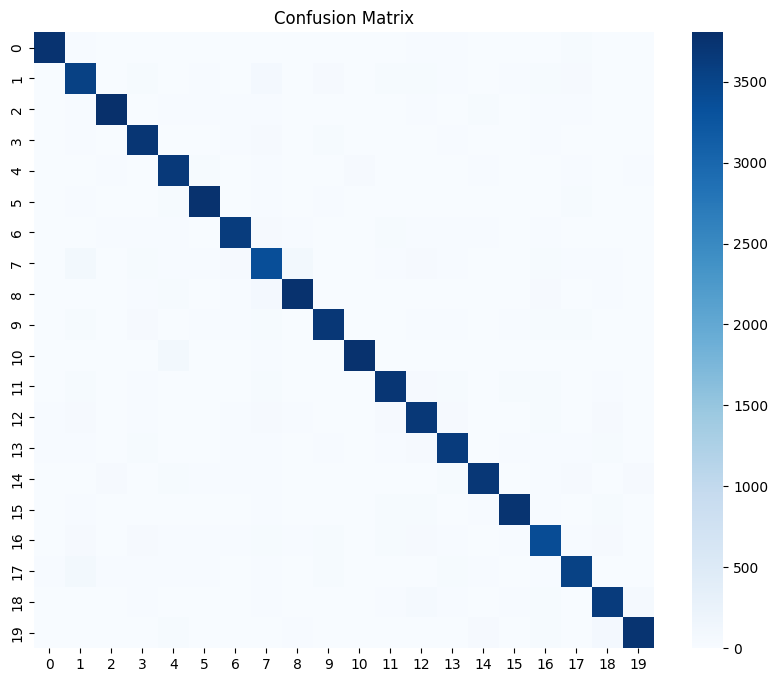

In [83]:
evaluate_confusion(val_loader)